Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (3).csv

=== FIRST 5 ROWS ===

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fibe

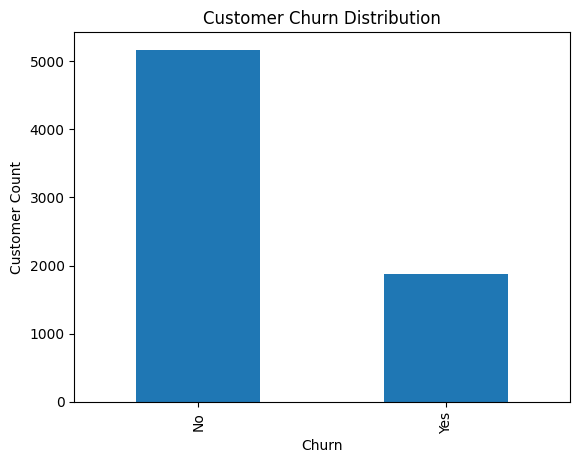


=== MISSING VALUES ===

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

LOGISTIC REGRESSION RESULTS

Accuracy:
0.7882018479033405

Confusion Matrix:
[[915 118]
 [180 194]]

AUC:
0.7022430903189402

RANDOM FOREST RESULTS

Accuracy:
0.7896233120113717

Confusion Matrix:
[[929 104]
 [192 182]]

AUC:
0.6929766890475278


In [10]:
# =========================================
# TELCO CUSTOMER CHURN ANALYSIS PROJECT
# PYTHON PROGRAMLAMA DÖNEM ÖDEVİ
# =========================================

# =========================
# DOSYA YÜKLEME
# =========================
from google.colab import files

uploaded = files.upload()

# =========================
# KÜTÜPHANELER
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# VERİ SETİNİ OKUMA
# =========================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# =========================
# İLK 5 SATIR
# =========================
print("\n=== FIRST 5 ROWS ===\n")

print(df.head())

# =========================
# VERİ BİLGİLERİ
# =========================
print("\n=== DATA INFO ===\n")

print(df.info())

# =========================
# SAYISAL ÖZET
# =========================
print("\n=== DESCRIBE ===\n")

print(df.describe())

# =========================
# CHURN DAĞILIMI
# =========================
print("\n=== CHURN DISTRIBUTION ===\n")

print(df["Churn"].value_counts())

# =========================
# GRAFİK
# =========================
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Customer Count")

plt.show()

# =========================
# GEREKSİZ SÜTUNU SİL
# =========================
df.drop("customerID", axis=1, inplace=True)

# =========================
# TotalCharges SAYISALA ÇEVİR
# =========================
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# =========================
# EKSİK VERİ KONTROLÜ
# =========================
print("\n=== MISSING VALUES ===\n")

print(df.isnull().sum())

# =========================
# EKSİK VERİLERİ TEMİZLE
# =========================
df.dropna(inplace=True)

# =========================
# KATEGORİK VERİLERİ SAYISALA ÇEVİR
# =========================
df = pd.get_dummies(df, drop_first=True)

# =========================
# X VE y AYIRMA
# =========================
X = df.drop("Churn_Yes", axis=1)

y = df["Churn_Yes"]

# =========================
# TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================
# LOGISTIC REGRESSION
# =========================================
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

# =========================
# TAHMİN
# =========================
y_pred = model.predict(X_test)

# =========================
# SONUÇLAR
# =========================
print("\n===================================")
print("LOGISTIC REGRESSION RESULTS")
print("===================================\n")

print("Accuracy:")

print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, y_pred))

print("\nAUC:")

print(roc_auc_score(y_test, y_pred))

# =========================================
# RANDOM FOREST
# =========================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# =========================
# RANDOM FOREST SONUÇLARI
# =========================
print("\n===================================")
print("RANDOM FOREST RESULTS")
print("===================================\n")

print("Accuracy:")

print(accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, rf_pred))

print("\nAUC:")

print(roc_auc_score(y_test, rf_pred))